# Sentiment Classification Project

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


# Verify Setup
Make sure cuda (GPU) is available

In [ ]:
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

CUDA Available: True
Device Name: NVIDIA GeForce RTX 5060 Ti


/home/trachsele/.conda/envs/my-cil-env/lib/python3.14/site-packages/torch/cuda/__init__.py:371: UserWarning: Found GPU0 NVIDIA GeForce RTX 5060 Ti which is of compute capability (CC) 12.0.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 5.0 which supports hardware CC >=5.0,<6.0 except {5.3}
- 6.0 which supports hardware CC >=6.0,<7.0 except {6.2}
- 7.0 which supports hardware CC >=7.0,<8.0 except {7.2}
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
Please follow the instructions at https://pytorch.org/get-started/locally/ to install a PyTorch release that supports one of these CUDA versions: 12.8, 13.0
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/trachsele/.conda/envs/my-cil-env/lib/python3.14/site-packages/torch/cuda/__init__.py:489: UserWarning: 
NVIDIA GeForce R

# Analyze Dataset
Lets first have a look what kind of data we have. Print first rows

In [ ]:
train_full = pd.read_csv("/cluster/courses/cil/text-classification/data/train.csv")
print(train_full[5:10])
print("\n\n")
print("-" * 50)
print("\n\n")
print(train_full["sentence"].iloc[6])

In [10]:
# see how big the dataset is
# Detailed summary of the dataframe
print("--- Dataset Overview ---")
train_full.info(memory_usage='deep')

# Just the numbers
rows, cols = train_full.shape
print(f"\nRows: {rows:,}")
print(f"Columns: {cols}")

--- Dataset Overview ---
<class 'pandas.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   id        252000 non-null  int64
 1   sentence  252000 non-null  str  
 2   label     252000 non-null  int64
dtypes: int64(2), str(1)
memory usage: 77.1 MB

Rows: 252,000
Columns: 3


Value Counts:
 label
4    50400
1    50400
0    50400
2    50400
3    50400
Name: count, dtype: int64

Percentage:
 label
4    20.0
1    20.0
0    20.0
2    20.0
3    20.0
Name: proportion, dtype: float64


<Axes: title={'center': 'Distribution of Sentiments'}, xlabel='label'>

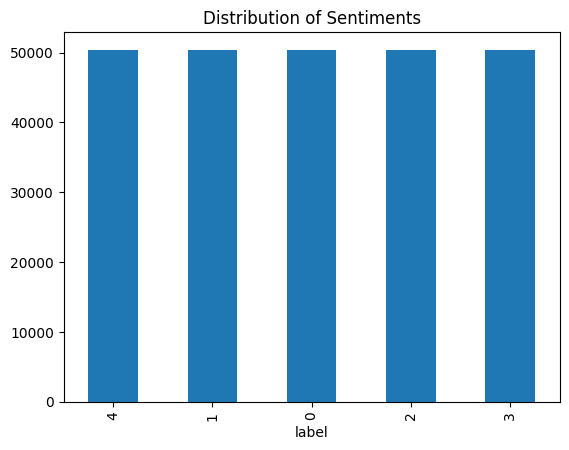

In [ ]:
# see how the labels are distributed

label_counts = train_full['label'].value_counts()
label_perc = train_full['label'].value_counts(normalize=True) * 100

print("Value Counts:\n", label_counts)
print("\nPercentage:\n", label_perc)

import matplotlib 
# Quick visualization
label_counts.plot(kind='bar', title='Distribution of Sentiments')

In [ ]:
# Calculate how many words per sample we have, to get a sense of how long the sentences are. This will help us choose a max_length for tokenization later on.
train_full['word_count'] = train_full['sentence'].apply(lambda x: len(str(x).split()))

print("--- Sentence Length Stats ---")
print(train_full['word_count'].describe())

# Check the 95th percentile - a good rule of thumb for max_length
p95 = train_full['word_count'].quantile(0.95)
print(f"\n95% of sentences are shorter than {p95} words.")

--- Sentence Length Stats ---
count    252000.000000
mean         37.497016
std          32.718396
min           2.000000
25%          16.000000
50%          28.000000
75%          47.000000
max         737.000000
Name: word_count, dtype: float64

95% of sentences are shorter than 98.0 words.


# Data preprocessing
We need to preprocess data. Step that come to my mind:
 - Remove word count outliers. (The vibe of a review comes across after 100 words or so).
 - We have german and english data. Should we translate everything to english
 - Should we search for smiley an insert text for them.
 - Should we search for ** (bold markers) and emphasize this word differenetly? 

# Build Validation Set
Todo: 

Currently we use 90% of the reviews for training, and the remaining 10% for validation
This should be optimized. Use k-fold validation or something like that to get most of our data as training and enable proper hyperparameter tuning later on.

In [11]:
train_df, val_df = train_test_split(
        train_full, test_size=0.1, stratify=train_full["label"], random_state=42
)

# Theory Summary and Plan

As far as I understand, we get sentences consisting of words. Now we want to map those words to some kind of numbers such that we have a numerical representation that the ML models can work with.

To do this, we have a vocabulary consisting of 30,000 or 40,000 tokens that lets us express all sentences that exist. I don't fully understand how people came up with a vocabulary, but basically what I have read, with an algorithm, they found out those 30,000 tokens are enough to express a huge amount of text (Wikipedia entries, Reddit).

This vocabulary is now a great help to us: It lets us map our English sentences consisting of words to the vocabulary (containing tokens where a token is just an int id: `token_id`)). Then the sentence is now just a sequence of `[token_ids]`.

Now this is where the magic happens. For every token given by (`token_id`), we choose a $\mathbb{R}^n$ representation (embedding) of it, such that tokens with similar meaning, e.g., ("love"), have a similar $\mathbb{R}^n$ representation (embedding). Let's call $n = \text{embedding\_dim}$. This is where the spark invention was (I think) that launched ChatGPT etc. 

For our model we now just need to map this embedding to ratings. I think we output a probablity (between 0 and 1) for every different rating. Then we predict the label by choosing the most likely probability

# Model ideas
First we always need to map the word sentences to sequences of token_ids. Then initial input $x$ to our models always is a sequence of integers (Token IDs) with dimensions $(\text{max\_tokens\_per\_sentence})$. 

## Baselines
The current baseline implementation follows the structure:
$$\text{Output} = \text{Classifier}(\text{EmbeddingForTokens}(x))$$

In this specific case:
* **EmbeddingForTokens**: They use `CountVectorizer`, which creates a "Bag of Words" representation (counting word frequencies).
* **Classifier**: They use **Logistic Regression**.

We could implement additional baselines by choosing more complex **EmbeddingForTokens** methods (such as word-level embeddings or pre-trained vectors) and more sophisticated **Classifier** models (such as Random Forests or simple Neural Networks (MLP)).

## PreTrained Bert

An idea would be to use a state of the art model (e.g BERT) to come up with embeddings. Then just use a classifer.
$$\text{My\_model} = \text{Classifier}(\text{BERT}(\text{x}))$$

Please note Bert takes as input just the sequence of integers (Token IDs) and comes up with the embedding for the tokens internally.

I think on our (smallish) dataset, the state-of-the-art models would overfit. An idea would be to just use a pretrained BERT model. Then we don't train BERT anymore but just a classifier which gives us a rating for every word.

Something more fancy could be: 
Freeze the pretrained Bert again and then in between the Classifier and BERT, we insert an adapter layer which we train on the dataset. This adapter layer should intuitively fine-tune the output from BERT ("the meaning of the sentences") to our dataset.

$$\text{My\_model} = \text{Classifier}(\text{Adapter}(\text{BERT}(\text{x})))$$




# Tokenization TODO
Generally the task is:

 $"\text{sentences}" \rightarrow \text{max\_sequence\_length}$

 where $\text{max\_sequence\_length}$ is the longest sequence of token_ids in our dataset.


In [13]:
from sklearn.feature_extraction.text import CountVectorizer

In [14]:
# We only keep the 10'000 most frequent words and bigrams (i.e. word pairs)
# This is both to reduce the computational cost and reduce potential overfitting
vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=10000)

In [15]:
# Important: Fit ONLY on training data
X_train = vectorizer.fit_transform(train_df["sentence"])
X_val = vectorizer.transform(val_df["sentence"])

Y_train = train_df["label"]
Y_val = val_df["label"]

In [17]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8225669 stored elements and shape (226800, 10000)>

In [16]:
print(X_train[2])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 154 stored elements and shape (1, 10000)>
  Coords	Values
  (0, 7116)	3
  (0, 52)	6
  (0, 2550)	3
  (0, 5789)	1
  (0, 2340)	1
  (0, 71)	1
  (0, 7060)	1
  (0, 5367)	3
  (0, 7053)	1
  (0, 911)	1
  (0, 6420)	1
  (0, 1949)	6
  (0, 3829)	1
  (0, 5081)	1
  (0, 9084)	3
  (0, 759)	2
  (0, 2363)	1
  (0, 2275)	1
  (0, 8698)	3
  (0, 7065)	1
  (0, 2338)	1
  (0, 638)	4
  (0, 1831)	3
  (0, 3851)	1
  (0, 5980)	1
  :	:
  (0, 4242)	1
  (0, 320)	1
  (0, 7295)	1
  (0, 2346)	1
  (0, 3498)	1
  (0, 3994)	1
  (0, 2578)	1
  (0, 4261)	1
  (0, 8795)	1
  (0, 9100)	1
  (0, 57)	2
  (0, 648)	1
  (0, 9874)	1
  (0, 907)	1
  (0, 5351)	1
  (0, 5750)	1
  (0, 8764)	1
  (0, 5369)	1
  (0, 725)	1
  (0, 4252)	1
  (0, 1731)	1
  (0, 2055)	1
  (0, 4546)	1
  (0, 640)	1
  (0, 307)	1


# Model
**TODO**: Train a model.

See  Model ideas

Currently, they just train a basic classifier (logistic regression classifier...).

I think Bert, chatgpt etc are all based on transformers. 

### How do Transformers work? (gemini)

The process of turning raw tokens into contextualized representations follows this sequence:

1. **Input Representation**: The initial input $x$ is a sequence of integers (Token IDs) with dimensions $(\text{max\_tokens\_per\_sentence})$. 

2. **Embedding Lookup**: We apply an `nn.Embedding` layer, which acts as a lookup table. This transforms the discrete IDs into continuous vectors. If you pass a sequence of length $L$ (your `max_seq_len`) into an embedding layer with dimension $D$, the final output of the lookup is a matrix of shape $(L, D)$. This layer is learned by the model during training.

3. **Positional Encodings: The Addition**: Because Transformers process all tokens in parallel, they lack an inherent sense of order. To fix this, we add **Positional Encodings** to the embeddings. This provides the model with information about the relative position of words.
   
   $$= x_{\text{input\_internal}} = \text{Embedding}(x) + \text{PositionalEncoding}$$


4. **Self-Attention Step**: The model creates three "views" of the input using learned weight matrices $W_Q, W_K,$ and $W_V$. The Query Q is the "Question" each person is asking.
The Key K is the "Name Tag" each person is wearing.
The Value V is the "Knowledge" each person actually has.
   
   $$Q = X \cdot W_Q \quad (\text{Result: } L \times D)$$
   $$K = X \cdot W_K \quad (\text{Result: } L \times D)$$
   $$V = X \cdot W_V \quad (\text{Result: } L \times D)$$

   where $$ X = x_{\text{input\_internal}} $$

   These are then used to calculate the attention scores:
   
   $$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

   * **Scaling Factor ($\sqrt{d_k}$)**: This is used for mathematical "damage control." By dividing by the square root of the dimension of the key vectors ($d_k$), we prevent the dot products from growing too large, which would cause the softmax function to saturate and stop the model from learning.

5. **Residual Connection and Normalization**: To ensure stability and help gradients flow, the attention output is added back to the original input (Residual Connection) and normalized.
   
   $$\text{Output}_1 = \text{LayerNorm}(x_{\text{input\_internal}} + \text{Attention\_Result})$$








In [ ]:
from sklearn.linear_model import LogisticRegression

In [19]:
# Logistic Regression Classifier, C: Inverse of regularization strength , max_iter: Maximum number of training iterations
model = LogisticRegression(C=1.0, max_iter=100)
model.fit(X_train, Y_train)

/home/trachsele/.conda/envs/my-cil-env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Evaluate model and Hyperparameter tuning
For all the different models we have hypertune them and evaluate them against each other.

In [20]:
Y_train_pred = model.predict(X_train)
Y_val_pred = model.predict(X_val)

In [21]:
from sklearn.metrics import mean_absolute_error

In [22]:
# score on training set
mae_train = mean_absolute_error(Y_train, Y_train_pred)
score_train = 1.0 - (mae_train / 4.0)
accuracy_train = np.mean(Y_train == Y_train_pred)

# score on validation set
mae_val = mean_absolute_error(Y_val, Y_val_pred)
score_val = 1.0 - (mae_val / 4.0)
accuracy_val = np.mean(Y_val == Y_val_pred)
    

print(f"Training Score: {score_train:.4f}, MAE: {mae_train:.4f}, Accuracy: {accuracy_train:.4f}")
print(f"Validation Score: {score_val:.4f}, MAE: {mae_val:.4f}, Accuracy: {accuracy_val:.4f}")

Training Score: 0.8880, MAE: 0.4480, Accuracy: 0.6436
Validation Score: 0.8698, MAE: 0.5208, Accuracy: 0.5807


# Make test submission

In [ ]:
test_df = pd.read_csv("data/test.csv")
X_test = vectorizer.transform(test_df["sentence"])

In [ ]:
submit_preds = model.predict(X_test)
submission = pd.DataFrame({
    "id": test_df["id"],
    "label": submit_preds
})

submission_path = "submissions/submission.csv"
submission.to_csv(submission_path, index=False)

# Model Interpretation

In [23]:
# Top N most Important Words & Word Pairs per Output Class (Pos, Neutral, Negative)
feature_names = vectorizer.get_feature_names_out() # get names of all tokens from vectorizer
coefs = model.coef_  # Weights per Feature for each Output Class; Shape: (Num_Output_Classes, Num_Features)

# Get Top_n Features by Weight for each Class
def get_top_features(class_index, top_n=10):
    class_coef = coefs[class_index]
    top_indices = np.argsort(class_coef)[-top_n:]
    return [feature_names[i] for i in reversed(top_indices)]

print("Top words & bigrams for 1 stars:", get_top_features(0))
print("Top words & bigrams for 2 star:", get_top_features(1))
print("Top words & bigrams for 3 stars:", get_top_features(2))
print("Top words & bigrams for 4 stars:", get_top_features(3))
print("Top words & bigrams for 5 stars:", get_top_features(4))

Top words & bigrams for 1 stars: ['one star', 'schrott', 'stern', 'müll', 'unbrauchbar', 'garbage', 'junk', 'horrible', 'unzufrieden', 'not good']
Top words & bigrams for 2 star: ['two stars', 'zwei sterne', 'naja', 'disappointing', 'enttäuscht', 'meh', 'poor', 'disappointed', 'not good', 'enttäuschend']
Top words & bigrams for 3 stars: ['three stars', 'abzug', 'drei sterne', 'geht so', 'sterne abzug', 'naja', 'okay', 'mittelmäßig', 'otherwise', 'meh']
Top words & bigrams for 4 stars: ['four stars', 'not bad', 'nicht schlecht', 'einziger', 'stern abzug', 'abzug', 'wieder kaufen', 'my only', 'guter', 'gutes']
Top words & bigrams for 5 stars: ['five stars', 'five', 'excellent', 'perfekt', 'tolles', 'not too', 'amazing', 'toller', 'awesome', 'klasse']


In [24]:
# Confusion Matrix - Negative, Neutral, Positive
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(Y_val,Y_val_pred, labels=[0,1,2,3,4])
print(conf_matrix)

[[3515 1067  321   74   63]
 [1241 2307 1188  208   96]
 [ 444 1202 2296  912  186]
 [ 105  198  844 2617 1276]
 [  68   59  141  873 3899]]


In [ ]:
results_df = val_df.copy()
results_df['predicted_label'] = Y_val_pred

results_df['diff'] = (results_df['label'] - results_df['predicted_label']).abs()
very_off = results_df[results_df['diff'] >= 3].sort_values(by='diff', ascending=False)

for i, row in very_off.head(10).iterrows():
    print(f"--- Review Snippet ---")
    print(f"{row['sentence'][:300]}...") # Increased to 300 to see more context
    print(f"Actual: {row['label']} | Predicted: {row['predicted_label']}")
    print("-" * 30 + "\n")